**Cell 1: Import Library yang Dibutuhkan**

In [1]:
# Cell 1: Import semua library yang dibutuhkan
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

print("Libraries berhasil di-import!")

Libraries berhasil di-import!


**Cell 2: Load & Cleaning Data**

In [2]:
# Cell 2: Membaca dataset dan melakukan pembersihan awal
# Pastikan file 'nps_surveys_with_feedback.csv' sudah di-upload ke Colab (menu Files di kiri)
file_path = 'nps_surveys_with_feedback.csv'
df = pd.read_csv(file_path)

# Menghapus baris yang kosong pada target (segment) atau fitur teks utama
df = df.dropna(subset=['segment', 'feedback_text'])

print(f"Total data siap pakai: {df.shape[0]} baris.")
df.head(3)

Total data siap pakai: 4549 baris.


,survey_id,customer_id,nps_score,survey_date,plan_type,contract_type,segment,feedback_category,feedback_text
0,SV-01430,C-0001,2.0,2024-12-02,Starter,Monthly,detractor,Account,Honestly this platform has been a total nightm...
1,SV-01431,C-0001,2.0,2024-04-27,Starter,Monthly,detractor,Account,After months of dealing with constant call dro...
2,SV-01928,C-0002,2.0,2024-04-01,Starter,Annual,detractor,Billing,Billing errors kept piling up and the invoices...


**Cell 3: Preprocessing (Teks & Kategorikal)**

In [3]:
# Cell 3: Ekstraksi fitur dan penyiapan data training/testing

# 1. Definisikan Fitur (X) dan Target (y)
X_text = df['feedback_text']
X_cat = df[['plan_type', 'contract_type', 'feedback_category']].fillna('Unknown')
y = df['segment']

# 2. Encode Target (Detractor, Passive, Promoter menjadi One-Hot)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_cat = to_categorical(y_encoded)

# 3. Ekstraksi Fitur Teks menggunakan TF-IDF
tfidf = TfidfVectorizer(max_features=1000, stop_words='english')
X_text_tf = tfidf.fit_transform(X_text).toarray()

# 4. Encoding Fitur Kategorikal menggunakan One-Hot Encoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_cat_ohe = ohe.fit_transform(X_cat)

# 5. Gabungkan kedua fitur (Teks + Kategorikal)
X = np.hstack((X_text_tf, X_cat_ohe))

# 6. Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Dimensi X_train: {X_train.shape}, Dimensi X_test: {X_test.shape}")

Dimensi X_train: (3639, 1014), Dimensi X_test: (910, 1014)


**Cell 4: Membangun Arsitektur MLP**

In [4]:
# Cell 4: Pembuatan Model Deep Learning (MLP) dengan Kapasitas Neuron Lebih Besar

# Bangun Arsitektur Model: 256 -> 128 -> 64
model = Sequential([
    # Hidden Layer 1: Kapasitas Besar untuk ekstraksi fitur awal
    Dense(256, activation='relu', input_shape=(X.shape[1],)),
    Dropout(0.4), # Dropout dinaikkan sedikit karena neuron lebih banyak (mencegah overfitting)

    # Hidden Layer 2
    Dense(128, activation='relu'),
    Dropout(0.3),

    # Hidden Layer 3
    Dense(64, activation='relu'),
    Dropout(0.2),

    # Output Layer (3 Kelas: Detractor, Passive, Promoter)
    Dense(3, activation='softmax')
])

# Compile Model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Tampilkan Ringkasan Arsitektur Model
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       259,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 301,187 (1.15 MB)

 Trainable params: 301,187 (1.15 MB)

 Non-trainable params: 0 (0.00 B)

**Cell 5: Training Model**

In [5]:
# Cell 5: Melatih model dengan data latih
epochs_count = 20
batch_size_count = 32

history = model.fit(
    X_train, y_train,
    epochs=epochs_count,
    batch_size=batch_size_count,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7279 - loss: 0.6454 - val_accuracy: 0.8571 - val_loss: 0.4256
Epoch 2/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8788 - loss: 0.3760 - val_accuracy: 0.8791 - val_loss: 0.3933
Epoch 3/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9124 - loss: 0.2915 - val_accuracy: 0.8901 - val_loss: 0.3787
Epoch 4/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9285 - loss: 0.2223 - val_accuracy: 0.8764 - val_loss: 0.4295
Epoch 5/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9463 - loss: 0.1580 - val_accuracy: 0.8764 - val_loss: 0.4650
Epoch 6/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9606 - loss: 0.1176 - val_accuracy: 0.8654 - val_loss: 0.5161
Epoch 7/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9786 - loss: 0.0672 - val_accuracy: 0.8544 - val_loss: 0.6365
Epoch 8/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9853 - loss: 0.0447 - val_accuracy: 0.

**Cell 6: Evaluasi Metrics (Precision, Recall, ROC-AUC)**

In [6]:
# Cell 6: Memprediksi data test dan menghitung seluruh metrik performa

y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# 1. Hitung Classification Report (Precision, Recall, F1)
print("\n=== CLASSIFICATION REPORT ===")
report = classification_report(y_true, y_pred, target_names=le.classes_)
print(report)

# 2. Hitung Overall Accuracy Score
acc_score = accuracy_score(y_true, y_pred)
print(f">> OVERALL ACCURACY SCORE: {acc_score:.4f}")

# 3. Hitung ROC-AUC Score (One-vs-Rest untuk Multi-class)
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')
print(f">> OVERALL ROC-AUC SCORE: {roc_auc:.4f}")

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

   detractor       0.90      0.94      0.92       599
     passive       0.76      0.75      0.75       216
    promoter       0.77      0.62      0.69        95

    accuracy                           0.86       910
   macro avg       0.81      0.77      0.79       910
weighted avg       0.86      0.86      0.86       910

>> OVERALL ACCURACY SCORE: 0.8593
>> OVERALL ROC-AUC SCORE: 0.9176


**Cell 7:Visualisasi Grafik (Loss, Accuracy, dan ROC Curve)**

📊 1. INTERPRETASI GRAFIK TRAINING HISTORY
• Loss (Error): Semakin kurva turun mendekati angka 0, semakin baik.
• Accuracy (Akurasi): Semakin kurva naik mendekati angka 1.0 (100%), semakin baik.
• Overfitting Check: Jika garis 'Train' dan 'Val' (Validation) bergerak beriringan
  dan berdekatan, artinya model belajar dengan baik (tidak menghafal data saja).



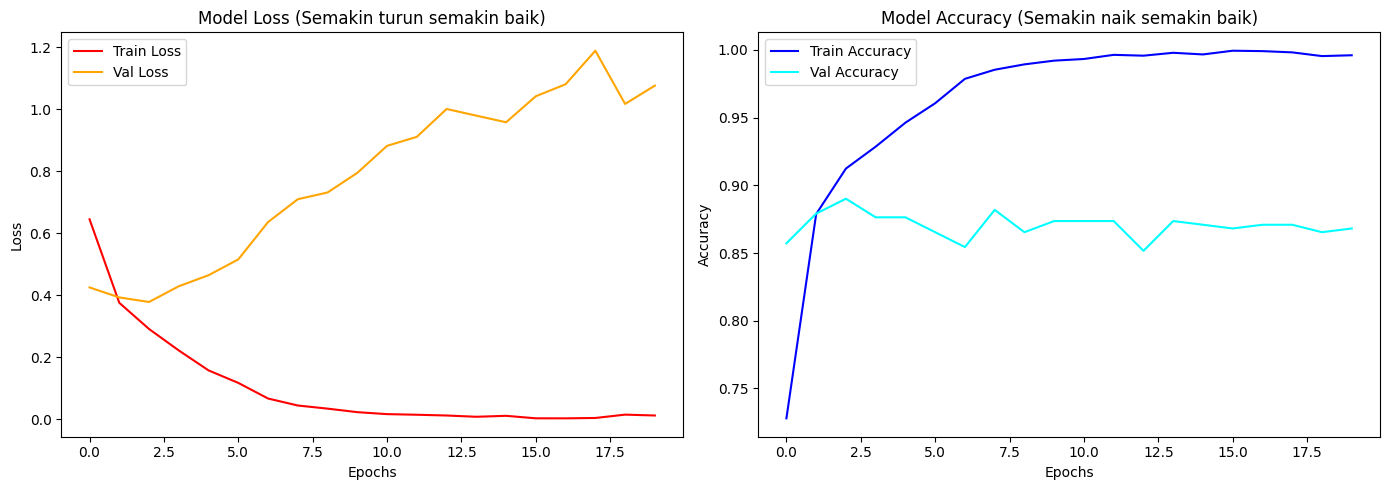


📈 2. INTERPRETASI GRAFIK ROC-AUC CURVE
• Kurva ini menunjukkan kemampuan model dalam membedakan masing-masing sentimen.
• Garis Putus-Putus Hitam: Adalah batas tebakan acak/random (AUC = 0.50).
• Nilai AUC (Area Under Curve): Berada di rentang 0 hingga 1.0.
  Semakin kurva melengkung ke sudut kiri atas (AUC mendekati 1.0),
  maka semakin akurat model mendeteksi kelas tersebut.



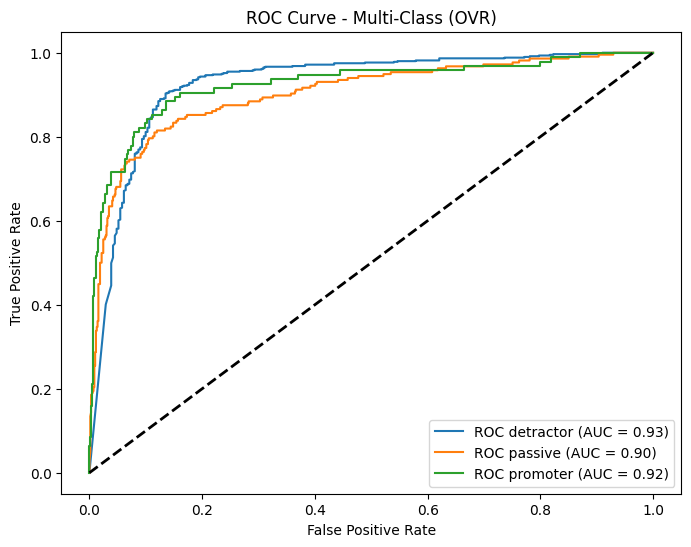

In [7]:
# Cell 7: Menampilkan Grafik Output Pembelajaran dan Performa Kelas beserta Penjelasannya

# --- PENJELASAN GRAFIK 1 ---
print("="*60)
print("📊 1. INTERPRETASI GRAFIK TRAINING HISTORY")
print("="*60)
print("• Loss (Error): Semakin kurva turun mendekati angka 0, semakin baik.")
print("• Accuracy (Akurasi): Semakin kurva naik mendekati angka 1.0 (100%), semakin baik.")
print("• Overfitting Check: Jika garis 'Train' dan 'Val' (Validation) bergerak beriringan")
print("  dan berdekatan, artinya model belajar dengan baik (tidak menghafal data saja).\n")

# Plot Training History (Loss & Accuracy)
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='red')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title('Model Loss (Semakin turun semakin baik)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='cyan')
plt.title('Model Accuracy (Semakin naik semakin baik)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# --- PENJELASAN GRAFIK 2 ---
print("\n" + "="*60)
print("📈 2. INTERPRETASI GRAFIK ROC-AUC CURVE")
print("="*60)
print("• Kurva ini menunjukkan kemampuan model dalam membedakan masing-masing sentimen.")
print("• Garis Putus-Putus Hitam: Adalah batas tebakan acak/random (AUC = 0.50).")
print("• Nilai AUC (Area Under Curve): Berada di rentang 0 hingga 1.0.")
print("  Semakin kurva melengkung ke sudut kiri atas (AUC mendekati 1.0),")
print("  maka semakin akurat model mendeteksi kelas tersebut.\n")

# Plot ROC-AUC Curve
plt.figure(figsize=(8, 6))
for i in range(3): # Looping untuk 3 kelas
    fpr, tpr, _ = roc_curve(y_test[:, i], y_pred_prob[:, i])
    roc_auc_class = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC {le.classes_[i]} (AUC = {roc_auc_class:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2) # Garis diagonal baseline
plt.title('ROC Curve - Multi-Class (OVR)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

**Cell 8: Export File (Model H5 & CSV Metrics)**

In [8]:
# Cell 8: Menyimpan model hasil training dan mengekstrak report ke tabel CSV
# Simpan Model Deep Learning
model.save('mlp_nps_model.keras')

# Konversi classification report ke DataFrame lalu simpan ke CSV
report_dict = classification_report(y_true, y_pred, target_names=le.classes_, output_dict=True)
metrics_df = pd.DataFrame(report_dict).transpose()
metrics_df['ROC_AUC_OVR'] = roc_auc # Menambahkan kolom ROC AUC untuk referensi

metrics_df.to_csv('evaluation_metrics_output.csv')

print("\n[SUKSES] Model tersimpan di 'mlp_nps_model.keras'")
print("[SUKSES] Tabel matriks evaluasi tersimpan di 'evaluation_metrics_output.csv'")
display(metrics_df) # Menampilkan tabel rapi di dalam Colab




[SUKSES] Model tersimpan di 'mlp_nps_model.keras'
[SUKSES] Tabel matriks evaluasi tersimpan di 'evaluation_metrics_output.csv'


,precision,recall,f1-score,support,ROC_AUC_OVR
detractor,0.903537,0.938230,0.920557,599.000000,0.917551
passive,0.763033,0.745370,0.754098,216.000000,0.917551
promoter,0.766234,0.621053,0.686047,95.000000,0.917551
accuracy,0.859341,0.859341,0.859341,0.859341,0.917551
macro avg,0.810935,0.768218,0.786901,910.000000,0.917551
weighted avg,0.855853,0.859341,0.856564,910.000000,0.917551
